<a href="https://colab.research.google.com/github/ErikRidhoFirm/PCVK_Ganjil_2025/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MODUL 5 - Operasi Aritmatika dan Logika Gamma Correction, Image Depth, PSNR, Average Denoising, Image Masking**

**TUGAS PRAKTIKUM**

# **1. Pada percobaan ini, nilai Gamma akan diset dengan meminta masukan dari pengguna**

Memasukkan import library

In [1]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np

Memasukkan gambar

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Input Gamma dari user

 Gamma Correction pada citra 
----------------------------------
Masukkan nilai Gamma: 3


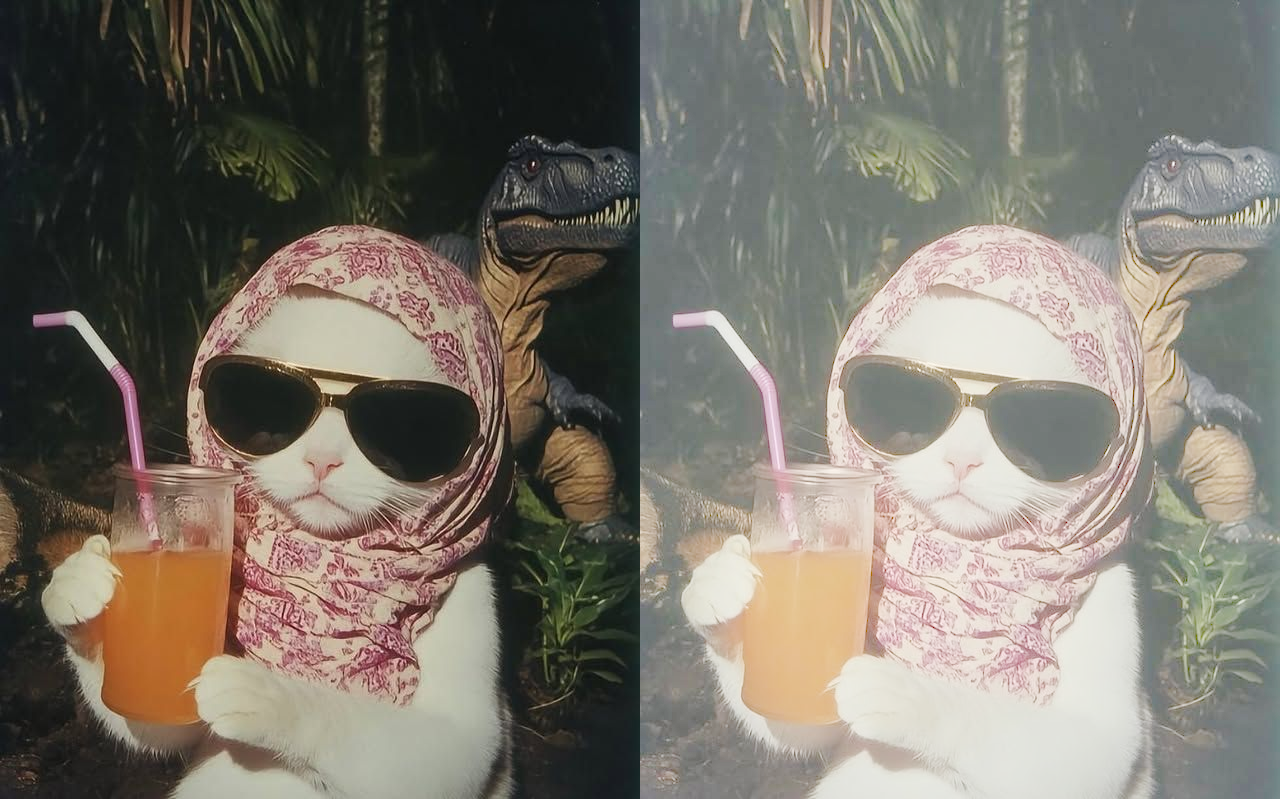

In [3]:
print(' Gamma Correction pada citra ')
print('----------------------------------')
try:
    gamma = float(input('Masukkan nilai Gamma: '))
except ValueError:
    print('Error, not a number')
    gamma = 1.0   # default kalau error

# Baca gambar
original = cv.imread('/content/drive/MyDrive/PCVK/Images1/cute_cat.jpeg')

# Normalisasi ke 0..1
img_float = original.astype(np.float32) / 255.0

# Rumus gamma correction: I' = 255 * (I/255)^(1/gamma)
gamma_corrected = np.power(img_float, 1.0 / gamma)
gamma_corrected = (gamma_corrected * 255).astype(np.uint8)

# Gabungkan hasil sebelum & sesudah
final_frame = cv.hconcat([original, gamma_corrected])
cv2_imshow(final_frame)

# **2. Buat Simulasi Image Depth**

Pada kuantisasi citra, pixel dapat direpresentasikan dengan n-bit kedalaman (default menggunakan 8-bit)  Pada pixel 8-bit, warna yang memungkinkan adalah 256 warna, dari 0 (0000 0000) hingga 255(1111 1111). Pada pixel 7-bit, warna yang memungkinkan adalah 128 warna, dari 0 (0000000) hingga 127 (111 1111). Kemungkinan warna didapat dari pangkat 2 jumlah bit. Jika 7bit, maka jumlah warnanya adalah 27 = 128, dst.

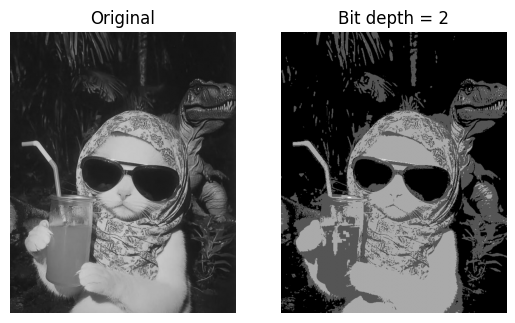

In [7]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

bit_depth = 2
level = 255 / (pow(2, bit_depth) - 1)
original = cv.imread('/content/drive/MyDrive/PCVK/Images1/cute_cat.jpeg', cv.IMREAD_GRAYSCALE)
depth_image = np.zeros(original.shape, original.dtype)

# Melakukan proses kuantisasi
depth_image = np.round(original / level) * level
depth_image = depth_image.astype(np.uint8)

# Menampilkan hasil
plt.subplot(1,2,1)
plt.imshow(original, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(depth_image, cmap='gray')
plt.title(f"Bit depth = {bit_depth}")
plt.axis('off')
plt.show()


# **3. Membuat modul Average Denoising**

Buat modul average denoising sesuai dengan rumus yang telah diberikan pada sub bab
sebelumnya.  
Citra asli sudah disediakan pada /images/galaxy.jpg.
100 Citra dengan Gaussian Noise sudah disediakan pada /images/noises/*.jpg
Anda dapat menggunakan code berikut untuk membaca semua image dalam satu folder ,
gunakan modul glob (import glob).

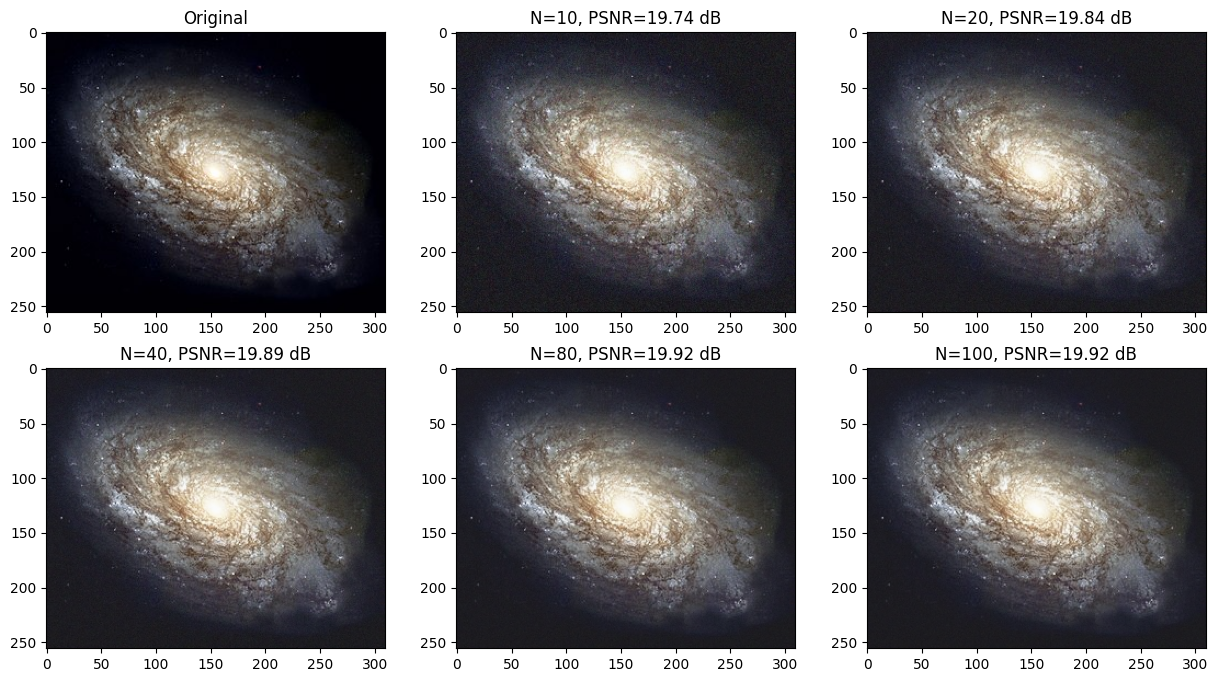

Tabel PSNR Average Denoising:
N	PSNR (dB)
10	19.74
20	19.84
40	19.89
80	19.92
100	19.92


In [11]:
import cv2 as cv
import numpy as np
import glob
import matplotlib.pyplot as plt

# Membaca citra asli
ori = cv.imread('/content/drive/MyDrive/PCVK/Images/galaxy.jpg')
ori = cv.cvtColor(ori, cv.COLOR_BGR2RGB)

# Membaca 100 citra noise
files = sorted(glob.glob('/content/drive/MyDrive/PCVK/Images/noises/*.jpg'))

cv_img = []
for img in files:
    n = cv.imread(img)
    n = cv.cvtColor(n, cv.COLOR_BGR2RGB)
    cv_img.append(n)   # simpan dalam float32

cv_img = np.array(cv_img)

# Fungsi PSNR
def psnr(target, ref):
    target = target.astype(np.float32)
    ref = ref.astype(np.float32)
    mse = np.mean((target - ref) ** 2)
    if mse == 0:
        return 100
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

# Average Denoising
def average_denoising(imgs, N):
    avg = np.mean(imgs[:N], axis=0)                # rata-rata N citra
    return np.clip(avg, 0, 255).astype(np.uint8)   # konversi ke citra normal

# Mengambil Ambil hasil untuk 10,20,40,80,100
counts = [10, 20, 40, 80, 100]
results = {}
for c in counts:
    denoised = average_denoising(cv_img, c)
    score = psnr(denoised, ori)
    results[c] = (denoised, score)

plt.figure(figsize=(15,8))

plt.subplot(2,3,1)
plt.imshow(ori)
plt.title("Original")

for i, c in enumerate(counts, start=2):
    plt.subplot(2,3,i)
    plt.imshow(results[c][0])
    plt.title(f"N={c}, PSNR={results[c][1]:.2f} dB")

plt.show()

print("Tabel PSNR Average Denoising:")
print("N\tPSNR (dB)")
for c in counts:
    print(f"{c}\t{results[c][1]:.2f}")


Pada gambar diatas dapat disimpulkan bahwa, Semakin banyak citra semakin baik kualitas nya, jadi secara umum terjadi peningkatan nilai PSNR seiring dengan bertambahnya jumlah citra berderau (noises image) (N) yang digunakan untuk proses perataan (averaging).
Adanya peningkatan mulai melambat meskipun terjadi peningkatan, laju peningkatnnya mulai melambat setelah N = 40.
Hukum pengembaliannya berkurang, Kesamaan nilai PSNR pada N=80 dan N = 100 menunjukkan bahwa penambahan jumlah citra di atas titik tertentu memberikan sedikit atau bahkan tidak ada manfaat tambahan yang signifikan dalam peningkatan kualitas citra (berdasarkan metrik PSNR). Yang artinya adanya titik di mana biaya komputasi untuk memproses lebih banyak citra tidak sebanding dengan peningkatan kualitas yang didapat.

# **4. Buat image masking untuk image berikut. Image kiri adalah image asli (images/couple.tiff), sedangkan image paling kanan adalah hasilnya:**

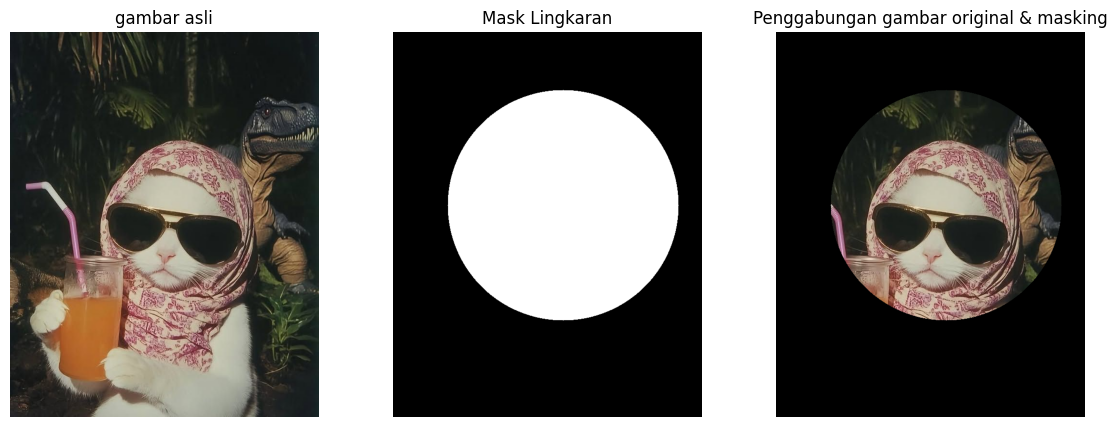

In [16]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

# Baca gambar
img = cv.imread('/content/drive/MyDrive/PCVK/Images1/cute_cat.jpeg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Buat mask kosong
mask = np.zeros(img.shape[:2], dtype="uint8")

# Menentukan posisi lingkaran untuk mengenai objek
center = (int(img.shape[1]*0.55), int(img.shape[0]*0.45))  # posisi lingkaran
radius = int(img.shape[0]*0.3)  # ukuran lingkaran untuk mengenai objek

# Gambar lingkaran putih di area wajah
cv.circle(mask, center, radius, 255, -1)

# Terapkan masking
masked = cv.bitwise_and(img, img, mask=mask)

# Tampilkan hasil
plt.figure(figsize=(14,5))
plt.subplot(1,3,1); plt.imshow(img); plt.title("gambar asli"); plt.axis("off")
plt.subplot(1,3,2); plt.imshow(mask, cmap="gray"); plt.title("Mask Lingkaran"); plt.axis("off")
plt.subplot(1,3,3); plt.imshow(masked); plt.title("Penggabungan gambar original & masking"); plt.axis("off")
plt.show()


# **5. Lakukan percobaan menggunakan operator lain dan tunjukkan hasilnya pada modul ini. Tuliskan hasil analisa anda kenapa citra keluarannya seperti itu**

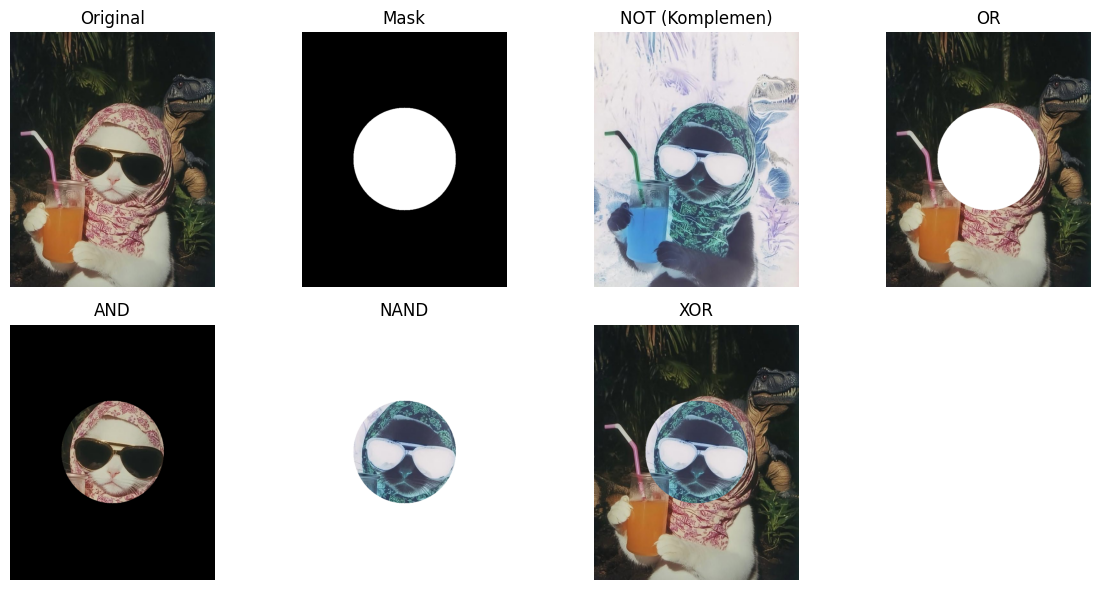

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Membaca citra
img = cv2.imread('/content/drive/MyDrive/PCVK/Images1/cute_cat.jpeg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Membuat mask lingkaran
mask = np.zeros(img.shape[:2], dtype="uint8")
h, w = img.shape[:2]
cv2.circle(mask, (w // 2, h // 2), min(h, w) // 4, 255, -1)

# Konversi mask ke 3 channel
mask_rgb = cv2.merge([mask, mask, mask])

# Operasi logika
and_result = cv2.bitwise_and(img, mask_rgb)
or_result = cv2.bitwise_or(img, mask_rgb)
xor_result = cv2.bitwise_xor(img, mask_rgb)
not_result = cv2.bitwise_not(img)
nand_result = cv2.bitwise_not(and_result)

# Menampilkan hasil
plt.figure(figsize=(12, 6))

plt.subplot(2, 4, 1)
plt.imshow(img)
plt.title('Original')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(mask, cmap='gray')
plt.title('Mask')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(not_result)
plt.title('NOT (Komplemen)')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(or_result)
plt.title('OR')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(and_result)
plt.title('AND')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(nand_result)
plt.title('NAND')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(xor_result)
plt.title('XOR')
plt.axis('off')

plt.tight_layout()
plt.show()


Ketika dianalisa, didapatkan jawaban:
1. Digunakannya gamma correction untuk mengatur kecerahan/kontras citra dengan transformasi non-linear
2. Pada percobaan ini bit depth berpengaruh pada jumlah gradasi warna. yang artinya semakin rendah bit depth nya semakin sederhana pula citra nya.
3. Pada average Denoising terbukti bisa mengurangi noise acak, dan PSNR menjadi matrik penting untuk mengukur kualitas hasil.
4. Operator logika (NOT, OR, AND, NAND, dan XOR) akan memberikan efek yang berbeda terhadap citra, dan dapat dimanfaatkan untuk berbagai aplikasi pengolahan citra seperti filtering, segmentasi, dan analisis citra.